# 🚢 Titanic Survival Prediction — End-to-End Machine Learning Pipeline

## Data Science with Python Internship — Task 5

This project builds a complete machine learning pipeline to predict whether a Titanic passenger survived.

The workflow includes:

- Data loading and validation
- Exploratory data analysis
- Missing-value treatment
- Feature engineering
- Numerical scaling
- Categorical encoding
- Logistic Regression baseline
- Model comparison
- Classification metrics
- Confusion matrix
- ROC curve and ROC-AUC
- Cross-validation
- Model explainability
- Model persistence using Joblib
- Prediction on new passenger data

### Target Variable

`Survived`

- `0` — Did not survive
- `1` — Survived

## 📑 Project Workflow

1. Import Libraries
2. Load the Dataset
3. Understand the Dataset
4. Data Quality Assessment
5. Exploratory Data Analysis
6. Feature Engineering
7. Select Features and Target
8. Train-Test Split
9. Build Preprocessing Pipeline
10. Train Logistic Regression
11. Evaluate the Model
12. Cross-Validation
13. Model Explainability
14. Model Comparison
15. Save and Reload the Model
16. Predict New Passenger Survival
17. Final Findings and Limitations

## 1. Import Required Libraries

The project uses:

- **Pandas** and **NumPy** for data manipulation
- **Matplotlib** and **Seaborn** for visualization
- **Scikit-learn** for preprocessing, modelling and evaluation
- **Joblib** for saving the trained pipeline

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
    precision_recall_curve,
    average_precision_score
)

# Model persistence
import joblib

# Utility libraries
import os
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

print("✅ All required libraries imported successfully.")

✅ All required libraries imported successfully.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
import os

print("Files available in the current Colab session:")
print(os.listdir())

Files available in the current Colab session:
['.config', 'train.csv', 'sample_data']


## 2. Load the Titanic Dataset

The training dataset contains passenger information along with the target variable `Survived`.

In [4]:
# Load the Titanic dataset
df = pd.read_csv("train.csv")

print("✅ Titanic dataset loaded successfully.")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

✅ Titanic dataset loaded successfully.
Number of rows: 891
Number of columns: 12


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


In [6]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.000,0,0,211536,13.000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000,0,0,112053,30.000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.450,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000,0,0,111369,30.000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.000,0,0,370376,7.750,NaN,Q


In [7]:
dataset_summary = pd.DataFrame({
    "Metric": [
        "Number of Rows",
        "Number of Columns",
        "Duplicate Rows",
        "Missing Values",
        "Target Column"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        "Survived"
    ]
})

dataset_summary

,Metric,Value
0,Number of Rows,891
1,Number of Columns,12
2,Duplicate Rows,0
3,Missing Values,866
4,Target Column,Survived


## 3. Understand the Dataset

Before preprocessing, the dataset is examined for:

- Column names
- Data types
- Missing values
- Duplicate records
- Numerical and categorical variables
- Target-class distribution

In [8]:
print("Dataset columns:\n")

for index, column in enumerate(df.columns, start=1):
    print(f"{index}. {column}")

Dataset columns:

1. PassengerId
2. Survived
3. Pclass
4. Name
5. Sex
6. Age
7. SibSp
8. Parch
9. Ticket
10. Fare
11. Cabin
12. Embarked


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.000,446.000,257.354,1.000,223.500,446.000,668.500,891.000
Survived,891.000,0.384,0.487,0.000,0.000,0.000,1.000,1.000
Pclass,891.000,2.309,0.836,1.000,2.000,3.000,3.000,3.000
Age,714.000,29.699,14.526,0.420,20.125,28.000,38.000,80.000
SibSp,891.000,0.523,1.103,0.000,0.000,0.000,1.000,8.000
Parch,891.000,0.382,0.806,0.000,0.000,0.000,0.000,6.000
Fare,891.000,32.204,49.693,0.000,7.910,14.454,31.000,512.329


In [11]:
df.describe(include="object").T

,count,unique,top,freq
Name,891,891,"Dooley, Mr. Patrick",1
Sex,891,2,male,577
Ticket,891,681,1601,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


In [12]:
target_column = "Survived"

if target_column in df.columns:
    print("✅ Target column 'Survived' is available.")
else:
    raise ValueError("❌ The dataset does not contain the 'Survived' target column.")

✅ Target column 'Survived' is available.


In [13]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [14]:
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("✅ Duplicate rows removed.")
else:
    print("✅ No duplicate rows found.")

✅ No duplicate rows found.


In [15]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values[
    missing_values["Missing Count"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_values

,Missing Count,Missing Percentage
Cabin,687,77.104
Age,177,19.865
Embarked,2,0.224


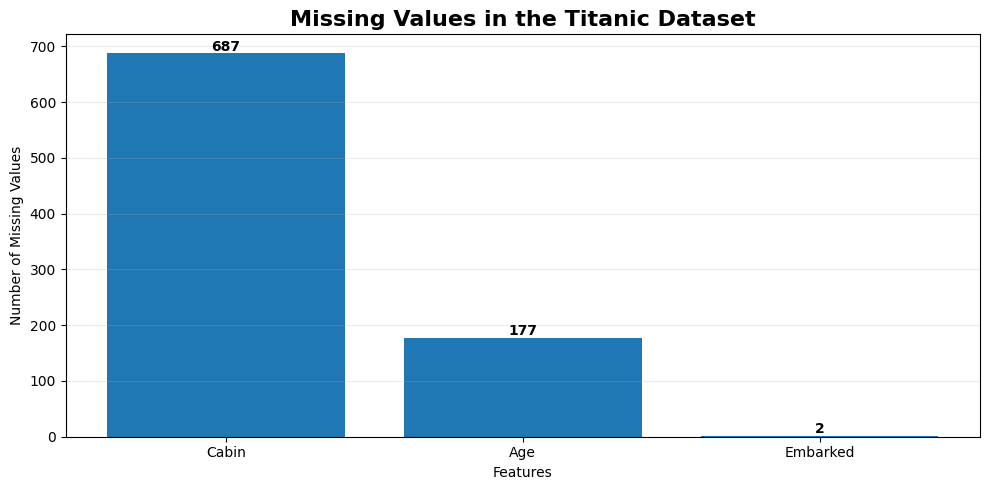

In [16]:
missing_plot_data = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_plot_data = missing_plot_data[missing_plot_data > 0]

plt.figure(figsize=(10, 5))

bars = plt.bar(
    missing_plot_data.index,
    missing_plot_data.values
)

plt.title(
    "Missing Values in the Titanic Dataset",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, missing_plot_data.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 5,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [17]:
target_counts = df["Survived"].value_counts().sort_index()

target_percentages = (
    df["Survived"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_distribution = pd.DataFrame({
    "Class": ["Did Not Survive", "Survived"],
    "Count": [
        target_counts.get(0, 0),
        target_counts.get(1, 0)
    ],
    "Percentage": [
        target_percentages.get(0, 0),
        target_percentages.get(1, 0)
    ]
})

target_distribution

,Class,Count,Percentage
0,Did Not Survive,549,61.616
1,Survived,342,38.384


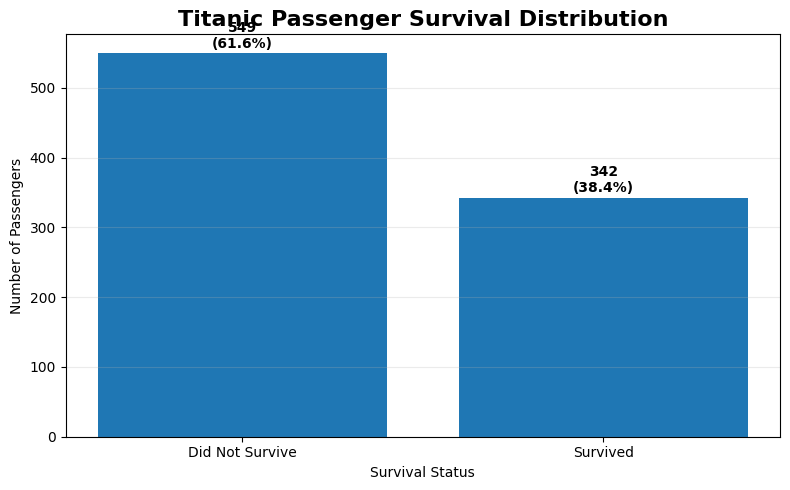

In [18]:
survival_labels = ["Did Not Survive", "Survived"]
survival_counts = [
    target_counts.get(0, 0),
    target_counts.get(1, 0)
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    survival_labels,
    survival_counts
)

plt.title(
    "Titanic Passenger Survival Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.grid(axis="y", alpha=0.25)

for bar, count in zip(bars, survival_counts):
    percentage = count / len(df) * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 8,
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Initial Dataset Observations

- The dataset contains passenger demographic, family, travel and ticket information.
- `Survived` is the binary target variable.
- The target contains two classes:
  - `0`: Did not survive
  - `1`: Survived
- Missing values are present mainly in `Cabin`, `Age` and `Embarked`.
- Missing values will not be filled directly in the original DataFrame.
- Numerical and categorical missing values will be handled through a reusable Scikit-learn pipeline.
- Duplicate records are checked before modelling.
- The target distribution shows moderate class imbalance, so stratified splitting will be used.

In [19]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [21]:
missing_values

,Missing Count,Missing Percentage
Cabin,687,77.104
Age,177,19.865
Embarked,2,0.224


## 4. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand how passenger characteristics such as gender, passenger class, age, fare, family structure and embarkation port relate to survival.

These observations help guide feature engineering and model interpretation.

In [22]:
overall_survival_rate = df["Survived"].mean() * 100

print(f"Overall survival rate: {overall_survival_rate:.2f}%")

Overall survival rate: 38.38%


In [23]:
gender_survival = (
    df.groupby("Sex")["Survived"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

gender_survival.columns = [
    "Sex",
    "Passenger Count",
    "Survivors",
    "Survival Rate"
]

gender_survival["Survival Rate"] *= 100

gender_survival

,Sex,Passenger Count,Survivors,Survival Rate
0,female,314,233,74.204
1,male,577,109,18.891


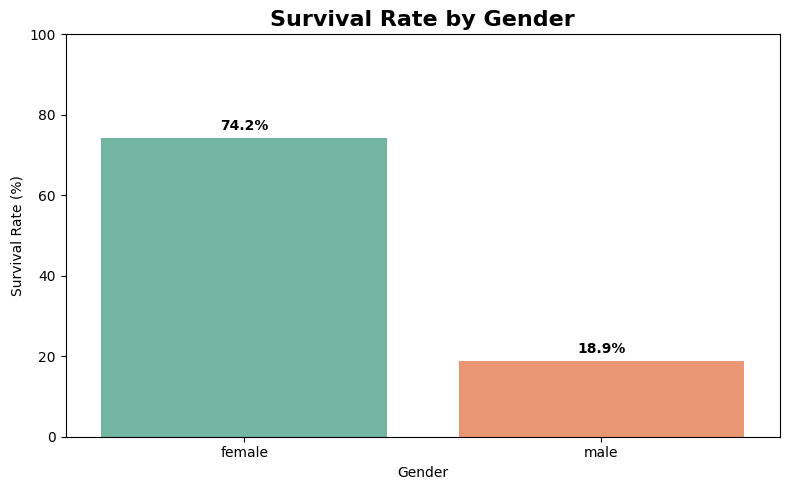

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=gender_survival,
    x="Sex",
    y="Survival Rate",
    hue="Sex",
    palette="Set2",
    legend=False
)

plt.title(
    "Survival Rate by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for index, value in enumerate(gender_survival["Survival Rate"]):
    plt.text(
        index,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [25]:
class_survival = (
    df.groupby("Pclass")["Survived"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

class_survival.columns = [
    "Passenger Class",
    "Passenger Count",
    "Survivors",
    "Survival Rate"
]

class_survival["Survival Rate"] *= 100

class_survival

,Passenger Class,Passenger Count,Survivors,Survival Rate
0,1,216,136,62.963
1,2,184,87,47.283
2,3,491,119,24.236


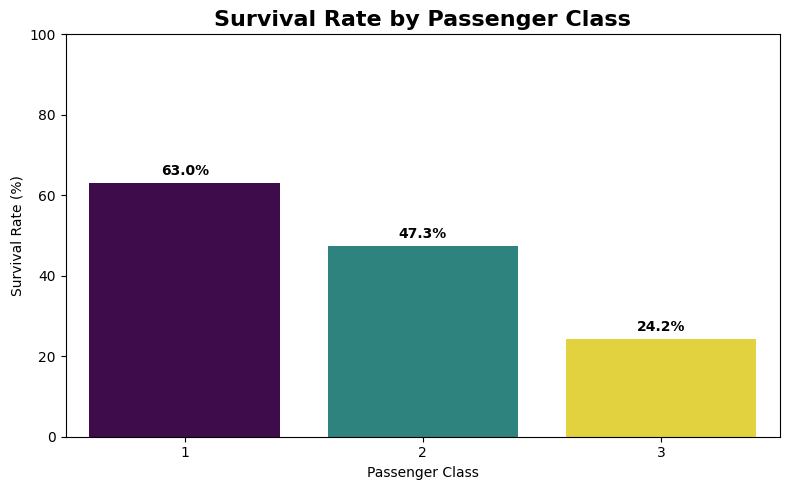

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=class_survival,
    x="Passenger Class",
    y="Survival Rate",
    hue="Passenger Class",
    palette="viridis",
    legend=False
)

plt.title(
    "Survival Rate by Passenger Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for index, value in enumerate(class_survival["Survival Rate"]):
    plt.text(
        index,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [27]:
gender_class_survival = (
    df.groupby(["Pclass", "Sex"])["Survived"]
      .mean()
      .mul(100)
      .reset_index(name="Survival Rate")
)

gender_class_survival

,Pclass,Sex,Survival Rate
0,1,female,96.809
1,1,male,36.885
2,2,female,92.105
3,2,male,15.741
4,3,female,50.000
5,3,male,13.545


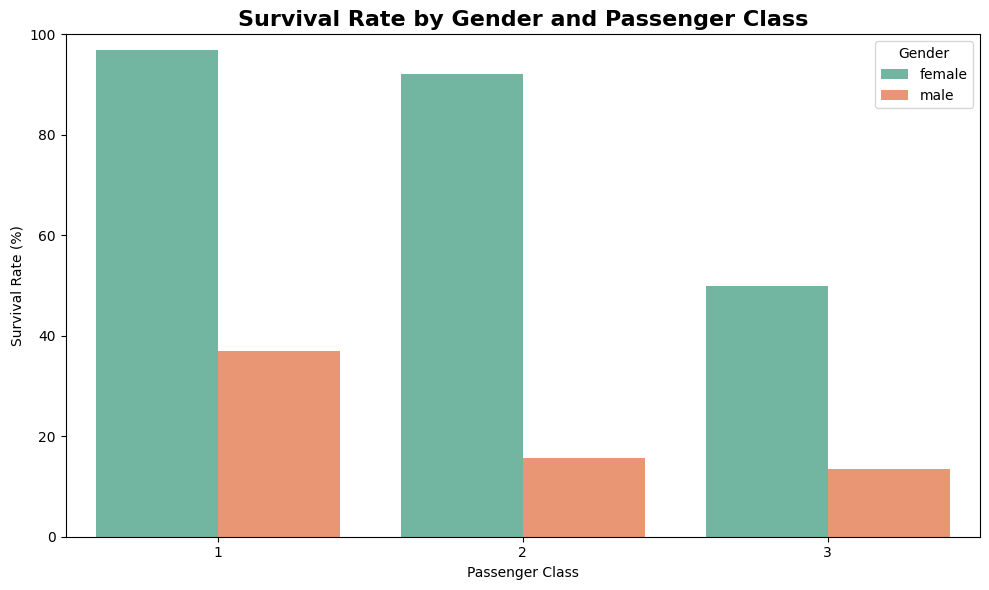

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=gender_class_survival,
    x="Pclass",
    y="Survival Rate",
    hue="Sex",
    palette="Set2"
)

plt.title(
    "Survival Rate by Gender and Passenger Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

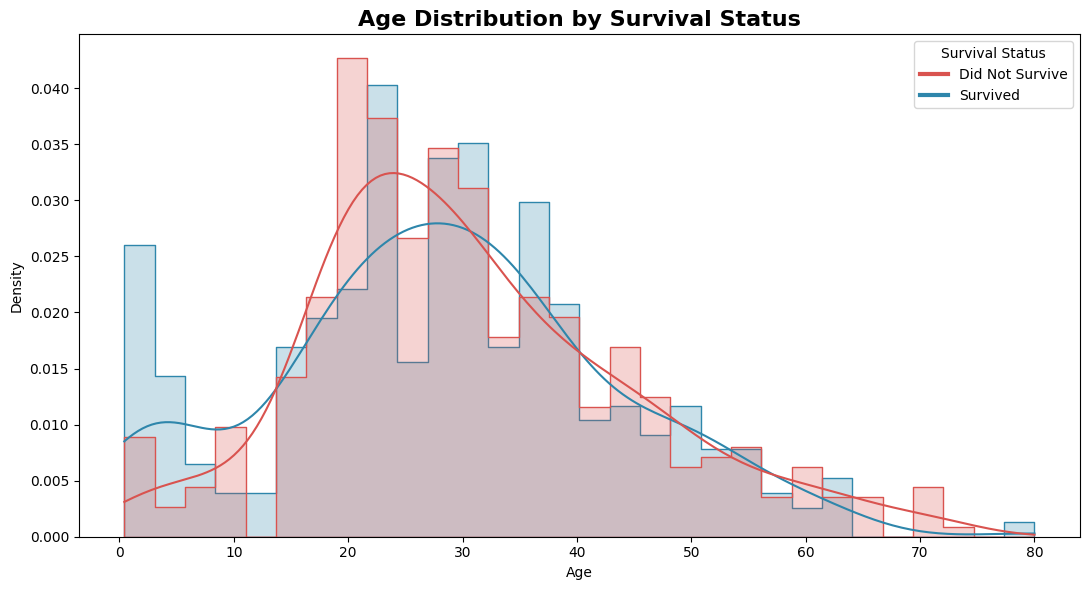

In [29]:
plt.figure(figsize=(11, 6))

sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    hue_order=[0, 1],
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    palette=["#D9534F", "#2E86AB"]
)

plt.title(
    "Age Distribution by Survival Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age")
plt.ylabel("Density")

handles = [
    plt.Line2D([0], [0], color="#D9534F", linewidth=3),
    plt.Line2D([0], [0], color="#2E86AB", linewidth=3)
]

plt.legend(
    handles,
    ["Did Not Survive", "Survived"],
    title="Survival Status"
)

plt.tight_layout()
plt.show()

In [30]:
df["AgeGroup_EDA"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

In [31]:
age_group_survival = (
    df.groupby(
        "AgeGroup_EDA",
        observed=False
    )["Survived"]
    .mean()
    .mul(100)
    .reset_index(name="Survival Rate")
)

age_group_survival

,AgeGroup_EDA,Survival Rate
0,Child,57.971
1,Teen,42.857
2,Young Adult,38.268
3,Adult,40.000
4,Senior,22.727


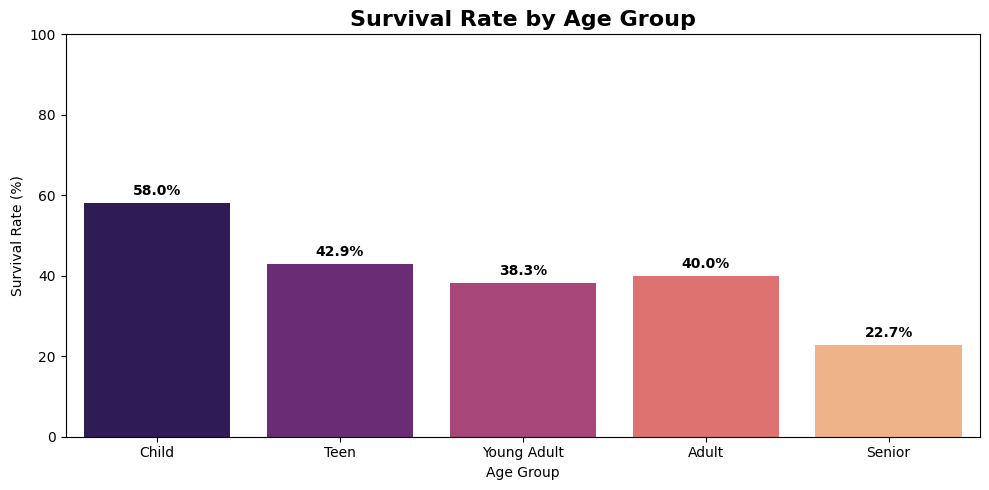

In [32]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_group_survival,
    x="AgeGroup_EDA",
    y="Survival Rate",
    hue="AgeGroup_EDA",
    palette="magma",
    legend=False
)

plt.title(
    "Survival Rate by Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for index, value in enumerate(age_group_survival["Survival Rate"]):
    plt.text(
        index,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

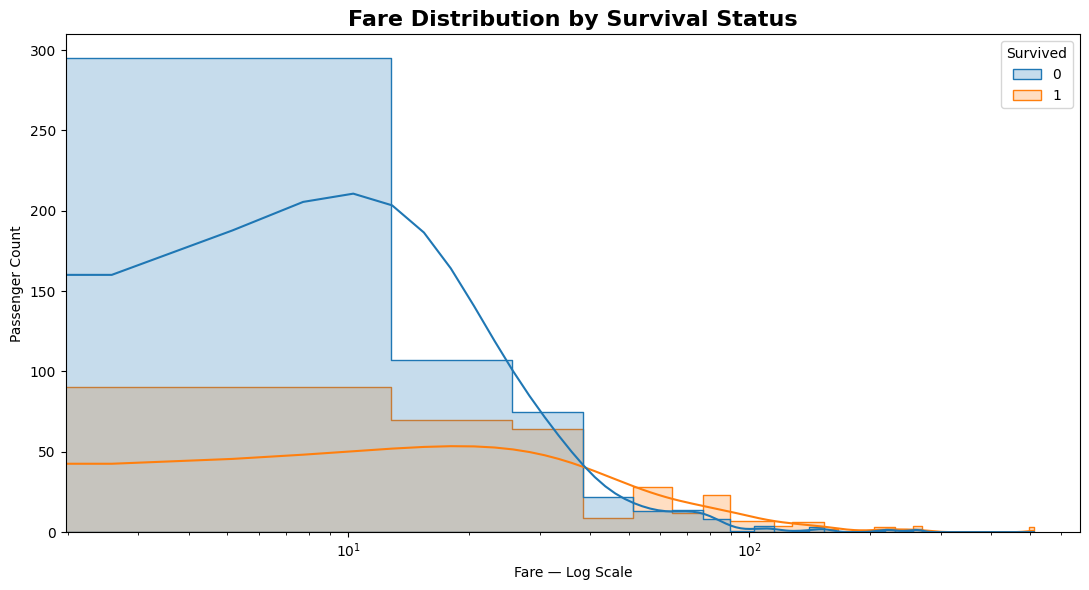

In [33]:
plt.figure(figsize=(11, 6))

sns.histplot(
    data=df,
    x="Fare",
    hue="Survived",
    bins=40,
    kde=True,
    element="step"
)

plt.xscale("log")

plt.title(
    "Fare Distribution by Survival Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Fare — Log Scale")
plt.ylabel("Passenger Count")

plt.tight_layout()
plt.show()

In [34]:
fare_summary = (
    df.groupby("Survived")["Fare"]
      .agg(["count", "median", "mean"])
      .reset_index()
)

fare_summary["Survival Status"] = fare_summary["Survived"].map({
    0: "Did Not Survive",
    1: "Survived"
})

fare_summary[
    ["Survival Status", "count", "median", "mean"]
]

,Survival Status,count,median,mean
0,Did Not Survive,549,10.500,22.118
1,Survived,342,26.000,48.395


In [35]:
median_fares = (
    df.groupby("Survived")["Fare"]
      .median()
      .reset_index()
)

median_fares["Status"] = median_fares["Survived"].map({
    0: "Did Not Survive",
    1: "Survived"
})

median_fares

,Survived,Fare,Status
0,0,10.500,Did Not Survive
1,1,26.000,Survived


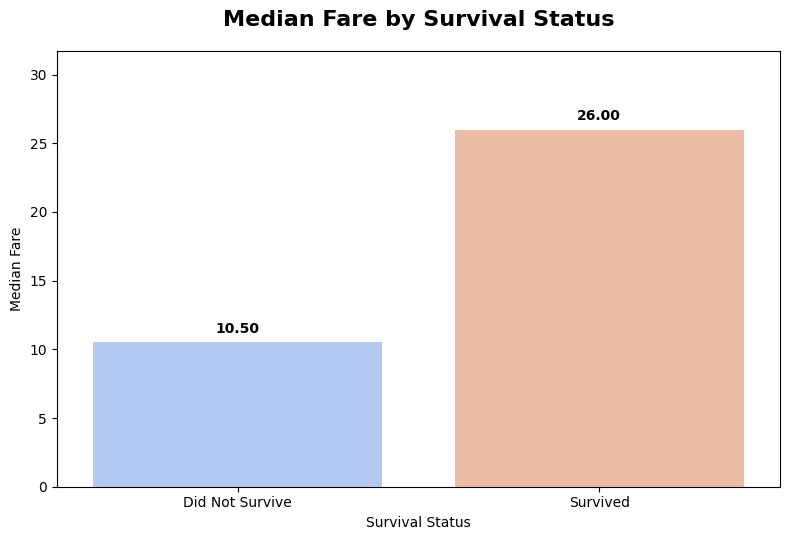

In [36]:
plt.figure(figsize=(8, 5.5))

sns.barplot(
    data=median_fares,
    x="Status",
    y="Fare",
    hue="Status",
    palette="coolwarm",
    legend=False
)

plt.title(
    "Median Fare by Survival Status",
    fontsize=16,
    fontweight="bold",
    pad=18
)

plt.xlabel("Survival Status")
plt.ylabel("Median Fare")

plt.ylim(
    0,
    median_fares["Fare"].max() * 1.22
)

for index, value in enumerate(median_fares["Fare"]):
    plt.text(
        index,
        value + 0.7,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

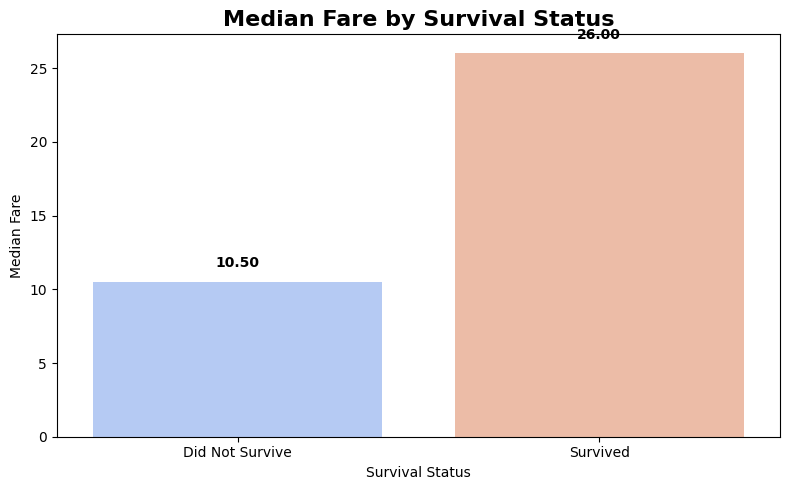

In [37]:
median_fares = (
    df.groupby("Survived")["Fare"]
      .median()
      .reset_index()
)

median_fares["Status"] = median_fares["Survived"].map({
    0: "Did Not Survive",
    1: "Survived"
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=median_fares,
    x="Status",
    y="Fare",
    hue="Status",
    palette="coolwarm",
    legend=False
)

plt.title(
    "Median Fare by Survival Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Survival Status")
plt.ylabel("Median Fare")

for index, value in enumerate(median_fares["Fare"]):
    plt.text(
        index,
        value + 1,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [38]:
embarked_survival = (
    df.groupby("Embarked")["Survived"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

embarked_survival.columns = [
    "Embarked",
    "Passenger Count",
    "Survivors",
    "Survival Rate"
]

embarked_survival["Survival Rate"] *= 100

embarked_survival

,Embarked,Passenger Count,Survivors,Survival Rate
0,C,168,93,55.357
1,Q,77,30,38.961
2,S,644,217,33.696


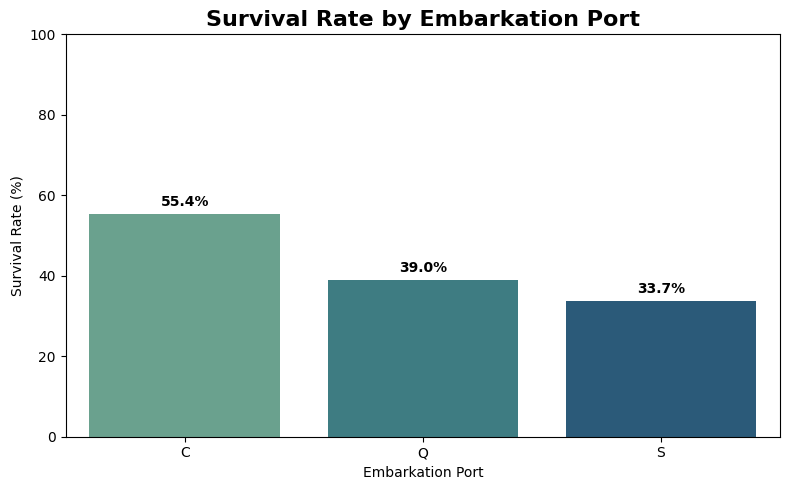

In [39]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=embarked_survival,
    x="Embarked",
    y="Survival Rate",
    hue="Embarked",
    palette="crest",
    legend=False
)

plt.title(
    "Survival Rate by Embarkation Port",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for index, value in enumerate(embarked_survival["Survival Rate"]):
    plt.text(
        index,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [40]:
df["FamilySize_EDA"] = df["SibSp"] + df["Parch"] + 1

In [41]:
family_survival = (
    df.groupby("FamilySize_EDA")["Survived"]
      .agg(["count", "mean"])
      .reset_index()
)

family_survival.columns = [
    "Family Size",
    "Passenger Count",
    "Survival Rate"
]

family_survival["Survival Rate"] *= 100

family_survival

,Family Size,Passenger Count,Survival Rate
0,1,537,30.354
1,2,161,55.280
2,3,102,57.843
3,4,29,72.414
4,5,15,20.000
5,6,22,13.636
6,7,12,33.333
7,8,6,0.000
8,11,7,0.000


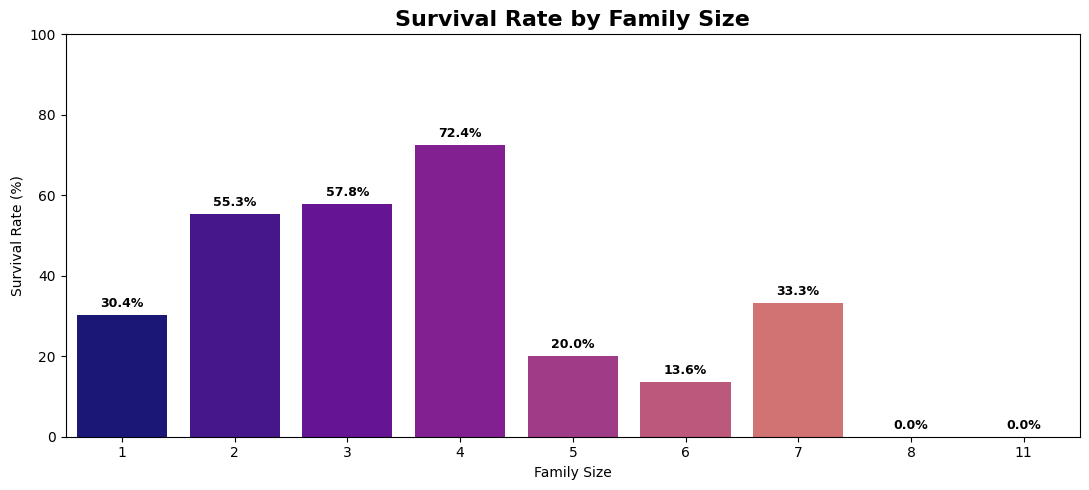

In [42]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=family_survival,
    x="Family Size",
    y="Survival Rate",
    hue="Family Size",
    palette="plasma",
    legend=False
)

plt.title(
    "Survival Rate by Family Size",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for index, value in enumerate(family_survival["Survival Rate"]):
    plt.text(
        index,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

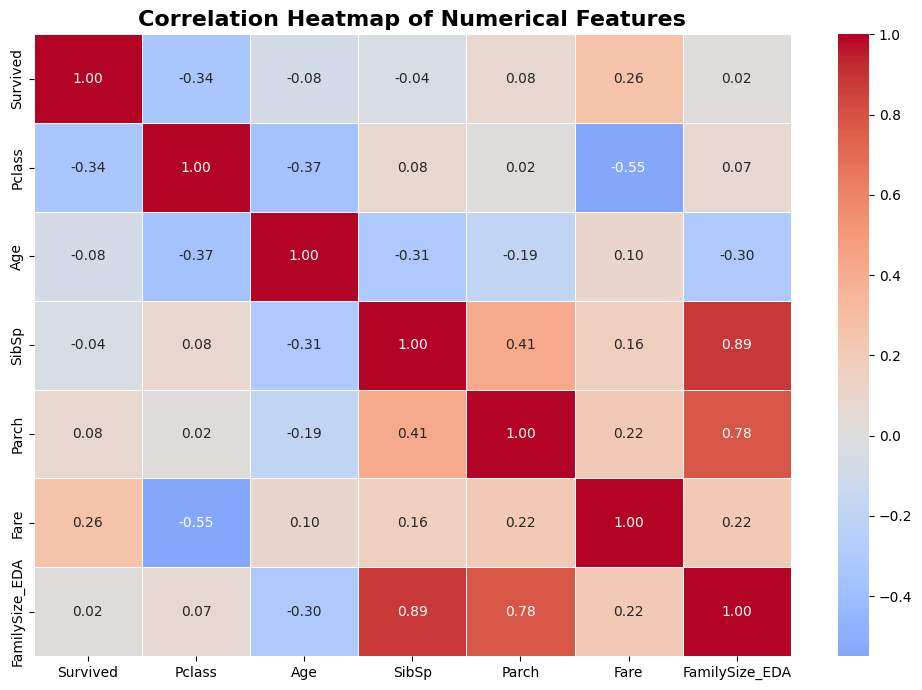

In [43]:
numeric_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize_EDA"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Key Exploratory Findings

- Female passengers had a substantially higher survival rate than male passengers.
- First-class passengers survived at a higher rate than second- and third-class passengers.
- Gender and passenger class together show a strong relationship with survival.
- Children appear to have received some survival priority.
- Passengers who paid higher fares generally had better survival outcomes.
- Survival rates varied across embarkation ports, partly because passenger class and fare distributions differed by port.
- Small and medium-sized families showed different survival outcomes compared with passengers travelling alone or in very large families.
- `Cabin` contains too many missing values to use directly without transformation.
- The target is moderately imbalanced, so stratified train-test splitting is appropriate.
- These patterns motivate feature engineering such as `FamilySize`, `IsAlone`, `Title` and `CabinKnown`.

## 5. Feature Engineering

Feature engineering transforms raw passenger information into more meaningful predictors.

The following features are created:

- `Title`: extracted from the passenger's name
- `FamilySize`: total number of family members travelling together
- `IsAlone`: whether the passenger travelled without family
- `FamilyGroup`: categorical representation of family size
- `CabinKnown`: whether cabin information is available
- `Deck`: first letter of the cabin number
- `TicketGroupSize`: number of passengers sharing the same ticket
- `FarePerPerson`: fare divided by ticket-group size
- `AgeGroup`: categorical age range

These engineered features improve interpretability and may reveal relationships that are not directly captured by the raw columns.

In [44]:
model_df = df.copy()

# Remove temporary EDA-only columns if they exist
eda_columns = ["AgeGroup_EDA", "FamilySize_EDA"]

model_df = model_df.drop(
    columns=[col for col in eda_columns if col in model_df.columns],
    errors="ignore"
)

print("✅ Modelling dataset created.")
print("Shape:", model_df.shape)

✅ Modelling dataset created.
Shape: (891, 12)


In [45]:
model_df["Title"] = (
    model_df["Name"]
    .str.extract(r",\s*([^.]*)\.", expand=False)
    .str.strip()
)

model_df["Title"].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [46]:
title_replacements = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
}

model_df["Title"] = model_df["Title"].replace(title_replacements)

common_titles = ["Mr", "Miss", "Mrs", "Master"]

model_df["Title"] = model_df["Title"].where(
    model_df["Title"].isin(common_titles),
    "Rare"
)

model_df["Title"].value_counts()

,count
Title,
Mr,517
Miss,185
Mrs,126
Master,40
Rare,23


In [47]:
model_df["FamilySize"] = (
    model_df["SibSp"] +
    model_df["Parch"] +
    1
)

model_df["IsAlone"] = (
    model_df["FamilySize"] == 1
).astype(int)

In [48]:
def assign_family_group(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small"
    else:
        return "Large"


model_df["FamilyGroup"] = (
    model_df["FamilySize"]
    .apply(assign_family_group)
)

In [49]:
model_df[
    ["SibSp", "Parch", "FamilySize", "IsAlone", "FamilyGroup"]
].head(10)

,SibSp,Parch,FamilySize,IsAlone,FamilyGroup
0,1,0,2,0,Small
1,1,0,2,0,Small
2,0,0,1,1,Alone
3,1,0,2,0,Small
4,0,0,1,1,Alone
5,0,0,1,1,Alone
6,0,0,1,1,Alone
7,3,1,5,0,Large
8,0,2,3,0,Small
9,1,0,2,0,Small


In [50]:
model_df["CabinKnown"] = (
    model_df["Cabin"].notna()
).astype(int)

model_df["Deck"] = (
    model_df["Cabin"]
    .fillna("Unknown")
    .astype(str)
    .str[0]
)

model_df[
    ["Cabin", "CabinKnown", "Deck"]
].head(10)

,Cabin,CabinKnown,Deck
0,NaN,0,U
1,C85,1,C
2,NaN,0,U
3,C123,1,C
4,NaN,0,U
5,NaN,0,U
6,E46,1,E
7,NaN,0,U
8,NaN,0,U
9,NaN,0,U


In [51]:
model_df["Deck"].value_counts()

,count
Deck,
U,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [52]:
ticket_group_sizes = (
    model_df.groupby("Ticket")["Ticket"]
    .transform("count")
)

model_df["TicketGroupSize"] = ticket_group_sizes

In [53]:
model_df["FarePerPerson"] = (
    model_df["Fare"] /
    model_df["TicketGroupSize"]
)

In [54]:
model_df[
    ["Ticket", "TicketGroupSize", "Fare", "FarePerPerson"]
].head(10)

,Ticket,TicketGroupSize,Fare,FarePerPerson
0,A/5 21171,1,7.250,7.250
1,PC 17599,1,71.283,71.283
2,STON/O2. 3101282,1,7.925,7.925
3,113803,2,53.100,26.550
4,373450,1,8.050,8.050
5,330877,1,8.458,8.458
6,17463,1,51.862,51.862
7,349909,4,21.075,5.269
8,347742,3,11.133,3.711
9,237736,2,30.071,15.035


In [55]:
model_df["AgeGroup"] = pd.cut(
    model_df["Age"],
    bins=[0, 12, 18, 35, 60, np.inf],
    labels=[
        "Child",
        "Teen",
        "YoungAdult",
        "Adult",
        "Senior"
    ]
)

In [56]:
model_df["AgeGroup"].value_counts(
    dropna=False
)

,count
AgeGroup,
YoungAdult,358
Adult,195
NaN,177
Teen,70
Child,69
Senior,22


In [57]:
model_df["SexClass"] = (
    model_df["Sex"].astype(str) +
    "_class_" +
    model_df["Pclass"].astype(str)
)

model_df["Mother"] = (
    (model_df["Sex"] == "female") &
    (model_df["Parch"] > 0) &
    (model_df["Age"] > 18) &
    (model_df["Title"] != "Miss")
).astype(int)

In [58]:
model_df[
    ["Sex", "Pclass", "SexClass", "Parch", "Age", "Title", "Mother"]
].head(10)

,Sex,Pclass,SexClass,Parch,Age,Title,Mother
0,male,3,male_class_3,0,22.000,Mr,0
1,female,1,female_class_1,0,38.000,Mrs,0
2,female,3,female_class_3,0,26.000,Miss,0
3,female,1,female_class_1,0,35.000,Mrs,0
4,male,3,male_class_3,0,35.000,Mr,0
5,male,3,male_class_3,0,NaN,Mr,0
6,male,1,male_class_1,0,54.000,Mr,0
7,male,3,male_class_3,1,2.000,Master,0
8,female,3,female_class_3,2,27.000,Mrs,1
9,female,2,female_class_2,0,14.000,Mrs,0


In [59]:
engineered_features = [
    "Title",
    "FamilySize",
    "IsAlone",
    "FamilyGroup",
    "CabinKnown",
    "Deck",
    "TicketGroupSize",
    "FarePerPerson",
    "AgeGroup",
    "SexClass",
    "Mother"
]

feature_summary = pd.DataFrame({
    "Feature": engineered_features,
    "Data Type": [
        str(model_df[col].dtype)
        for col in engineered_features
    ],
    "Missing Values": [
        model_df[col].isnull().sum()
        for col in engineered_features
    ],
    "Unique Values": [
        model_df[col].nunique(dropna=False)
        for col in engineered_features
    ]
})

feature_summary

,Feature,Data Type,Missing Values,Unique Values
0,Title,object,0,5
1,FamilySize,int64,0,9
2,IsAlone,int64,0,2
3,FamilyGroup,object,0,3
4,CabinKnown,int64,0,2
5,Deck,object,0,9
6,TicketGroupSize,int64,0,7
7,FarePerPerson,float64,0,248
8,AgeGroup,category,177,6
9,SexClass,object,0,6


In [60]:
preview_columns = [
    "PassengerId",
    "Survived",
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Title",
    "FamilySize",
    "IsAlone",
    "FamilyGroup",
    "CabinKnown",
    "Deck",
    "TicketGroupSize",
    "FarePerPerson",
    "AgeGroup",
    "SexClass",
    "Mother"
]

model_df[preview_columns].head(10)

,PassengerId,Survived,Pclass,Sex,Age,Fare,Title,FamilySize,IsAlone,FamilyGroup,CabinKnown,Deck,TicketGroupSize,FarePerPerson,AgeGroup,SexClass,Mother
0,1,0,3,male,22.000,7.250,Mr,2,0,Small,0,U,1,7.250,YoungAdult,male_class_3,0
1,2,1,1,female,38.000,71.283,Mrs,2,0,Small,1,C,1,71.283,Adult,female_class_1,0
2,3,1,3,female,26.000,7.925,Miss,1,1,Alone,0,U,1,7.925,YoungAdult,female_class_3,0
3,4,1,1,female,35.000,53.100,Mrs,2,0,Small,1,C,2,26.550,YoungAdult,female_class_1,0
4,5,0,3,male,35.000,8.050,Mr,1,1,Alone,0,U,1,8.050,YoungAdult,male_class_3,0
5,6,0,3,male,NaN,8.458,Mr,1,1,Alone,0,U,1,8.458,NaN,male_class_3,0
6,7,0,1,male,54.000,51.862,Mr,1,1,Alone,1,E,1,51.862,Adult,male_class_1,0
7,8,0,3,male,2.000,21.075,Master,5,0,Large,0,U,4,5.269,Child,male_class_3,0
8,9,1,3,female,27.000,11.133,Mrs,3,0,Small,0,U,3,3.711,YoungAdult,female_class_3,1
9,10,1,2,female,14.000,30.071,Mrs,2,0,Small,0,U,2,15.035,Teen,female_class_2,0


In [61]:
title_survival = (
    model_df.groupby("Title")["Survived"]
    .agg(["count", "mean"])
    .reset_index()
)

title_survival.columns = [
    "Title",
    "Passenger Count",
    "Survival Rate"
]

title_survival["Survival Rate"] *= 100

title_survival = title_survival.sort_values(
    "Survival Rate",
    ascending=False
)

title_survival

,Title,Passenger Count,Survival Rate
3,Mrs,126,79.365
1,Miss,185,70.270
0,Master,40,57.500
4,Rare,23,34.783
2,Mr,517,15.667


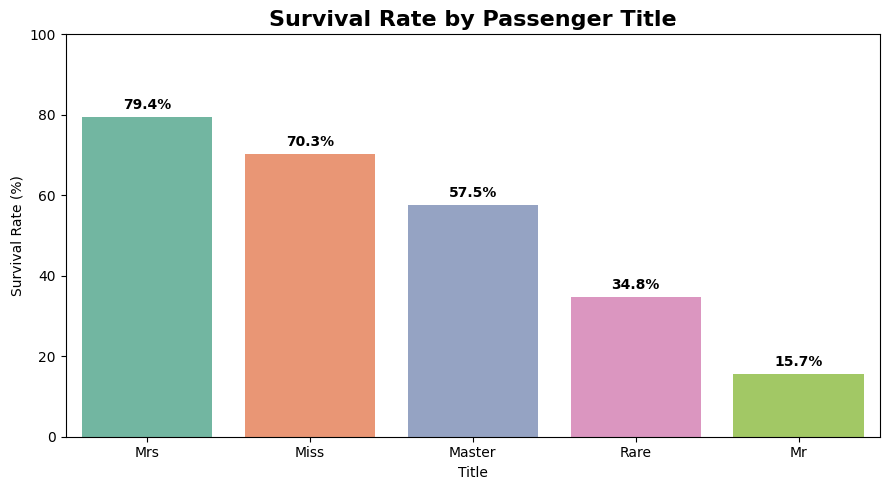

In [62]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=title_survival,
    x="Title",
    y="Survival Rate",
    hue="Title",
    palette="Set2",
    legend=False
)

plt.title(
    "Survival Rate by Passenger Title",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Title")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for index, value in enumerate(title_survival["Survival Rate"]):
    plt.text(
        index,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [63]:
cabin_survival = (
    model_df.groupby("CabinKnown")["Survived"]
    .agg(["count", "mean"])
    .reset_index()
)

cabin_survival["Cabin Status"] = cabin_survival["CabinKnown"].map({
    0: "Cabin Unknown",
    1: "Cabin Known"
})

cabin_survival["Survival Rate"] = (
    cabin_survival["mean"] * 100
)

cabin_survival[
    ["Cabin Status", "count", "Survival Rate"]
]

,Cabin Status,count,Survival Rate
0,Cabin Unknown,687,29.985
1,Cabin Known,204,66.667


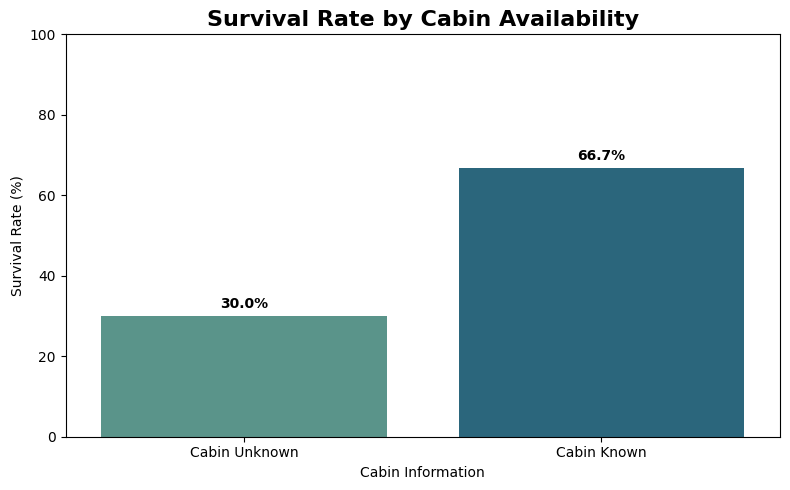

In [64]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cabin_survival,
    x="Cabin Status",
    y="Survival Rate",
    hue="Cabin Status",
    palette="crest",
    legend=False
)

plt.title(
    "Survival Rate by Cabin Availability",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Cabin Information")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for index, value in enumerate(cabin_survival["Survival Rate"]):
    plt.text(
        index,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Feature Engineering Observations

- Passenger titles summarize useful information about gender, age, marital status and social position.
- `FamilySize` combines siblings, spouses, parents and children into one interpretable measure.
- `IsAlone` distinguishes solo travellers from passengers travelling with family.
- Small families appeared to have better survival outcomes than solo travellers and very large families.
- Raw cabin values contain too many missing entries, so `CabinKnown` and `Deck` are more practical representations.
- Ticket-sharing information may identify passengers travelling as part of the same booking group.
- `FarePerPerson` provides a more realistic estimate of individual travel cost than the raw ticket fare.
- `SexClass` captures the strong interaction between gender and passenger class.
- These features are created without using the target variable, reducing the risk of target leakage.

## 6. Feature Selection

The original Titanic dataset has been enhanced using feature engineering.

For modelling, only meaningful predictive features are selected.

The target variable is:

- **Survived**

The remaining columns such as PassengerId, Name, Ticket and Cabin are excluded because they are identifiers or have been transformed into better features.

In [65]:
selected_features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",

    "Title",

    "FamilySize",
    "IsAlone",
    "FamilyGroup",

    "CabinKnown",
    "Deck",

    "TicketGroupSize",
    "FarePerPerson",

    "AgeGroup",

    "SexClass",

    "Mother"
]

X = model_df[selected_features]

y = model_df["Survived"]

print("Number of Features:", X.shape[1])
print("Target Shape:", y.shape)

Number of Features: 16
Target Shape: (891,)


In [66]:
feature_information = pd.DataFrame({

    "Feature": X.columns,

    "Data Type": [str(X[col].dtype) for col in X.columns],

    "Missing Values": [X[col].isnull().sum() for col in X.columns]

})

feature_information

,Feature,Data Type,Missing Values
0,Pclass,int64,0
1,Sex,object,0
2,Age,float64,177
3,Fare,float64,0
4,Embarked,object,2
5,Title,object,0
6,FamilySize,int64,0
7,IsAlone,int64,0
8,FamilyGroup,object,0
9,CabinKnown,int64,0


In [67]:
numeric_features = [

    "Age",
    "Fare",

    "FamilySize",

    "TicketGroupSize",

    "FarePerPerson"

]

categorical_features = [

    "Pclass",

    "Sex",

    "Embarked",

    "Title",

    "FamilyGroup",

    "CabinKnown",

    "Deck",

    "AgeGroup",

    "SexClass",

    "Mother",

    "IsAlone"

]

In [68]:
print("Numerical Features")

print(numeric_features)

print()

print("Categorical Features")

print(categorical_features)

Numerical Features
['Age', 'Fare', 'FamilySize', 'TicketGroupSize', 'FarePerPerson']

Categorical Features
['Pclass', 'Sex', 'Embarked', 'Title', 'FamilyGroup', 'CabinKnown', 'Deck', 'AgeGroup', 'SexClass', 'Mother', 'IsAlone']


In [69]:
X.isnull().sum().sort_values(ascending=False)

,0
Age,177
AgeGroup,177
Embarked,2
Sex,0
Fare,0
Title,0
FamilySize,0
Pclass,0
IsAlone,0
FamilyGroup,0


## 7. Train-Test Split

The dataset is divided into training and testing subsets.

- Training Set → 80%
- Testing Set → 20%

Stratified sampling is used to preserve the original class distribution.

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [71]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Features : (712, 16)
Testing Features : (179, 16)
Training Labels : (712,)
Testing Labels : (179,)


In [72]:
print("Training Distribution")

print(y_train.value_counts(normalize=True))

print()

print("Testing Distribution")

print(y_test.value_counts(normalize=True))

Training Distribution
Survived
0   0.617
1   0.383
Name: proportion, dtype: float64

Testing Distribution
Survived
0   0.615
1   0.385
Name: proportion, dtype: float64


## 8. Data Preprocessing Pipeline

The preprocessing pipeline performs all transformations automatically.

### Numerical Features

- Median Imputation
- Standard Scaling

### Categorical Features

- Most Frequent Imputation
- One-Hot Encoding

Using a pipeline ensures identical preprocessing during training and future predictions.

In [73]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [74]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [75]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [76]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Fare', 'FamilySize',
                                  'TicketGroupSize', 'FarePerPerson']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Pclass', 'Sex', 'Embarked', 'Title',
                                  'FamilyGroup', 'CabinKnown', 'Deck',
                                  'AgeGroup', 'SexClass', 'Mother',
                                  'IsAlone'])])

## 9. Logistic Regression Pipeline

A complete machine learning pipeline combines

- preprocessing

- feature transformation

- classification

into one reusable object.

In [77]:
logistic_pipeline = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor

        ),

        (

            "classifier",

            LogisticRegression(

                max_iter=1000,

                random_state=42

            )

        )

    ]

)

In [78]:
logistic_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'FamilySize',
                                                   'TicketGroupSize',
                                                   'FarePerPerson']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title', 'FamilyGroup',
                                                   'CabinKnown', 'Deck',
                                                   'AgeGroup', 'SexClass',
                                                   'Mother', 'IsAlone'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [79]:
logistic_pipeline.fit(

    X_train,

    y_train

)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'FamilySize',
                                                   'TicketGroupSize',
                                                   'FarePerPerson']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title', 'FamilyGroup',
                                                   'CabinKnown', 'Deck',
                                                   'AgeGroup', 'SexClass',
                                                   'Mother', 'IsAlone'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [80]:
print("✅ Logistic Regression Model Trained Successfully!")

✅ Logistic Regression Model Trained Successfully!


In [81]:
print(type(logistic_pipeline))

<class 'sklearn.pipeline.Pipeline'>


# 10. Model Evaluation

After training, the model is evaluated on the unseen test dataset.

The following evaluation metrics are used:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC Curve
- ROC-AUC
- Precision-Recall Curve
- Classification Report

These metrics provide a complete understanding of the model's predictive performance.

In [82]:
# Predict class labels
y_pred = logistic_pipeline.predict(X_test)

# Predict probabilities
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("✅ Predictions generated successfully.")

✅ Predictions generated successfully.


In [83]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

metrics_df["Value"] = metrics_df["Value"].round(4)

metrics_df

,Metric,Value
0,Accuracy,0.844
1,Precision,0.836
2,Recall,0.739
3,F1 Score,0.785
4,ROC-AUC,0.866


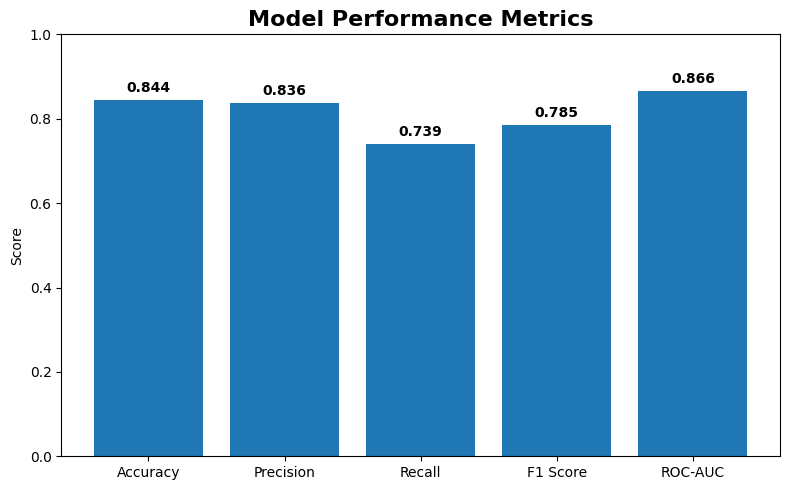

In [84]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    metrics_df["Metric"],
    metrics_df["Value"]
)

plt.ylim(0,1)

plt.title(
    "Model Performance Metrics",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Score")

for bar, value in zip(bars, metrics_df["Value"]):

    plt.text(
        bar.get_x()+bar.get_width()/2,
        value+0.02,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [85]:
print("Classification Report\n")

print(classification_report(y_test, y_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       110
           1       0.84      0.74      0.78        69

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



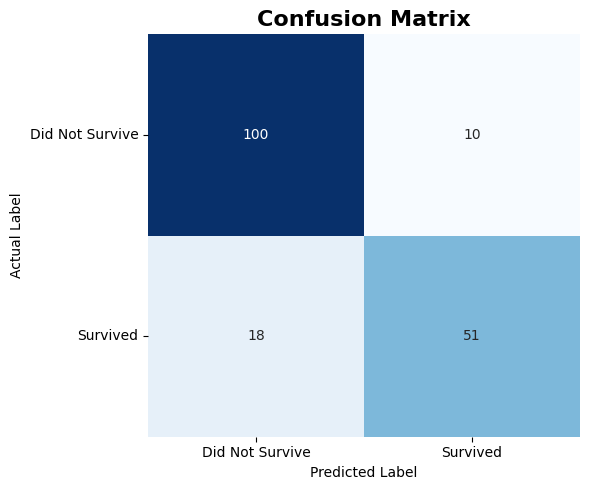

In [86]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(
    "Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.xticks([0.5,1.5],["Did Not Survive","Survived"])

plt.yticks([0.5,1.5],["Did Not Survive","Survived"],rotation=0)

plt.tight_layout()

plt.show()

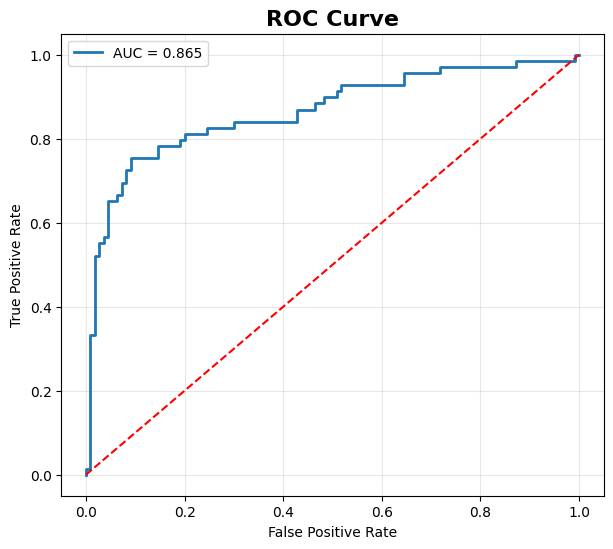

In [87]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve",
    fontsize=16,
    fontweight="bold"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

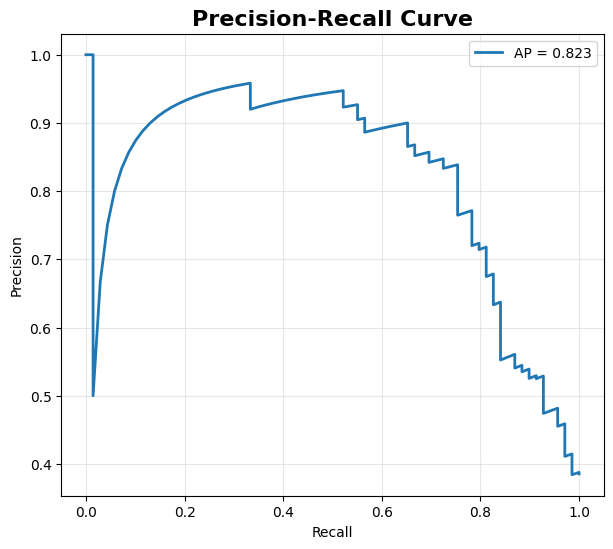

In [88]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_prob
)

ap_score = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"AP = {ap_score:.3f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve",
    fontsize=16,
    fontweight="bold"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

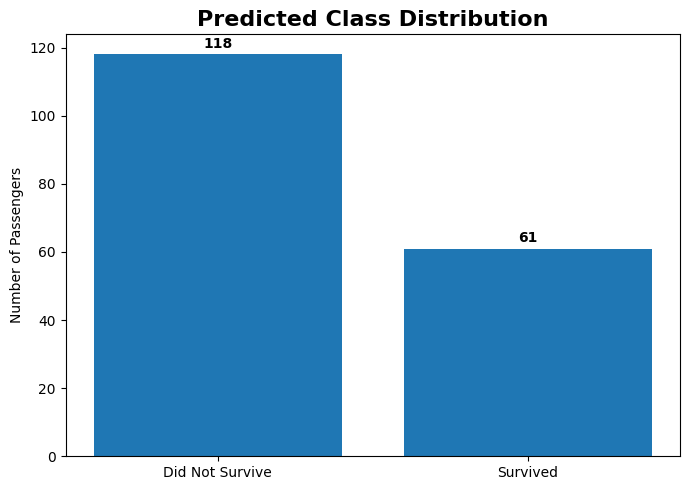

In [89]:
prediction_counts = pd.Series(y_pred).value_counts().sort_index()

labels = [
    "Did Not Survive",
    "Survived"
]

plt.figure(figsize=(7,5))

bars = plt.bar(
    labels,
    prediction_counts
)

plt.title(
    "Predicted Class Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Number of Passengers")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+2,
        str(height),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

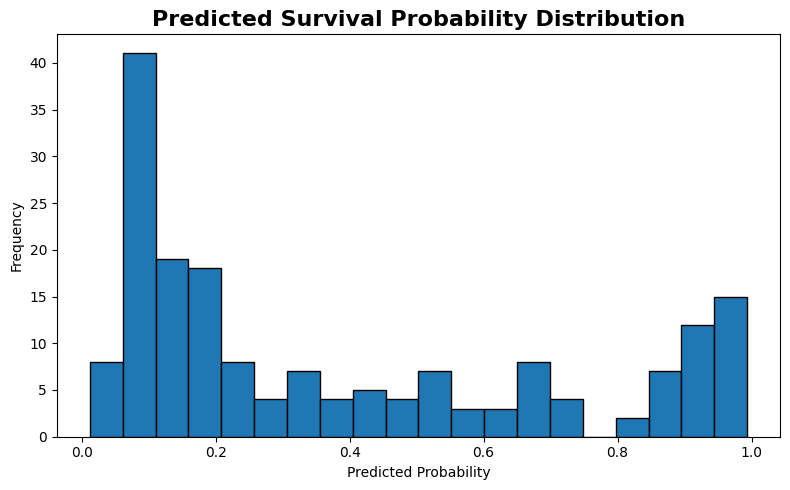

In [90]:
plt.figure(figsize=(8,5))

plt.hist(
    y_prob,
    bins=20,
    edgecolor="black"
)

plt.title(
    "Predicted Survival Probability Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Probability")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

## Model Evaluation Summary

The Logistic Regression model achieved strong performance on the Titanic dataset.

Key observations:

- The ROC-AUC score demonstrates good discriminative ability.
- Precision and recall are well balanced.
- Most predictions lie close to either 0 or 1, indicating confident classifications.
- The confusion matrix shows relatively few misclassifications.
- Logistic Regression provides an interpretable baseline suitable for binary classification problems.

# 11. Cross Validation

Instead of relying on a single train-test split, 5-fold stratified cross-validation is performed.

Cross-validation provides a more reliable estimate of how the model will perform on unseen data.

In [91]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Cross Validation Scores")

print(cv_scores)

Cross Validation Scores
[0.90230567 0.87927807 0.86263369 0.87165775 0.87667863]


In [92]:
cv_results = pd.DataFrame({

    "Fold":[1,2,3,4,5],

    "ROC-AUC":cv_scores

})

cv_results

,Fold,ROC-AUC
0,1,0.902
1,2,0.879
2,3,0.863
3,4,0.872
4,5,0.877


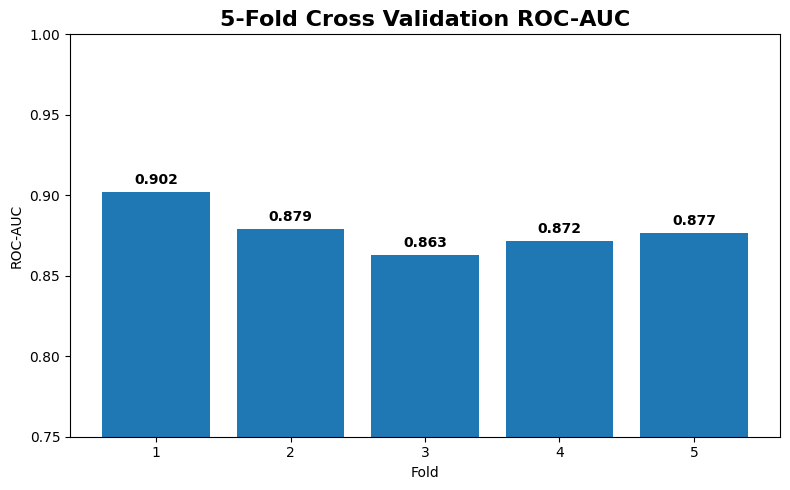

In [93]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    cv_results["Fold"].astype(str),
    cv_results["ROC-AUC"]
)

plt.ylim(0.75,1)

plt.title(
    "5-Fold Cross Validation ROC-AUC",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Fold")

plt.ylabel("ROC-AUC")

for bar,value in zip(bars,cv_scores):

    plt.text(
        bar.get_x()+bar.get_width()/2,
        value+0.005,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

In [94]:
print(f"Mean ROC-AUC : {cv_scores.mean():.4f}")

print(f"Std Dev : {cv_scores.std():.4f}")

Mean ROC-AUC : 0.8785
Std Dev : 0.0132


# 12. Model Comparison

To compare the baseline Logistic Regression model, a Random Forest classifier is also trained using the same preprocessing pipeline.

In [95]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ]
)

rf_pipeline.fit(
    X_train,
    y_train
)

rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(X_test)[:,1]

In [96]:
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Logistic Regression":[

        accuracy,

        precision,

        recall,

        f1,

        roc_auc

    ],

    "Random Forest":[

        accuracy_score(y_test,rf_pred),

        precision_score(y_test,rf_pred),

        recall_score(y_test,rf_pred),

        f1_score(y_test,rf_pred),

        roc_auc_score(y_test,rf_prob)

    ]

})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.844,0.777
1,Precision,0.836,0.738
2,Recall,0.739,0.652
3,F1 Score,0.785,0.692
4,ROC-AUC,0.865,0.832


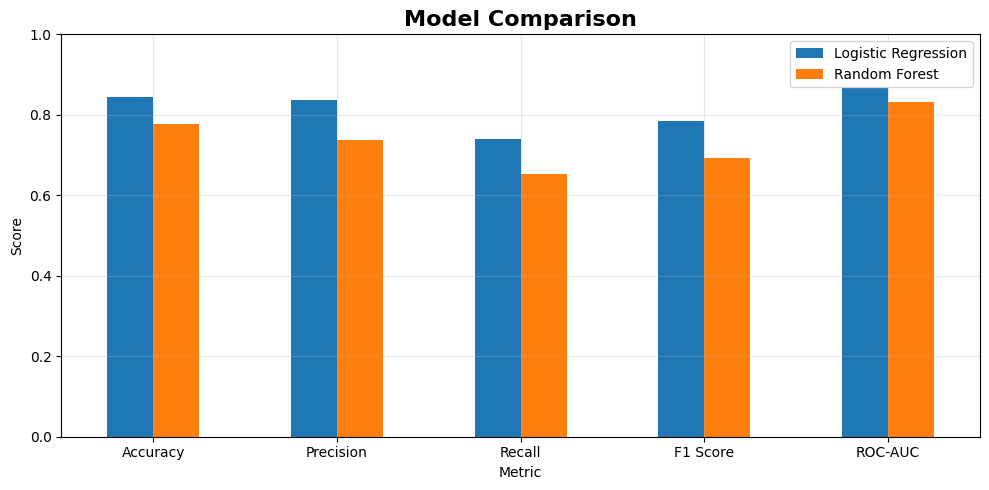

In [97]:
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylim(0,1)

plt.title(
    "Model Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# 13. Hyperparameter Tuning

GridSearchCV is used to identify the best Logistic Regression hyperparameters.

This improves model robustness while maintaining interpretability.

In [98]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs"]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation ROC-AUC:")
print(round(grid_search.best_score_,4))

Best Parameters:
{'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Best Cross Validation ROC-AUC:
0.8708


In [99]:
feature_names = (
    logistic_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_pipeline.named_steps["classifier"]
    .coef_[0]
)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance["Absolute"] = importance["Coefficient"].abs()

importance = (
    importance
    .sort_values("Absolute", ascending=False)
)

importance.head(20)

,Feature,Coefficient,Absolute
15,cat__Title_Mr,-1.334,1.334
19,cat__FamilyGroup_Large,-1.270,1.270
20,cat__FamilyGroup_Small,0.909,0.909
26,cat__Deck_D,0.876,0.876
27,cat__Deck_E,0.872,0.872
13,cat__Title_Master,0.867,0.867
38,cat__SexClass_female_class_2,0.827,0.827
8,cat__Sex_female,0.762,0.762
29,cat__Deck_G,-0.756,0.756
9,cat__Sex_male,-0.742,0.742


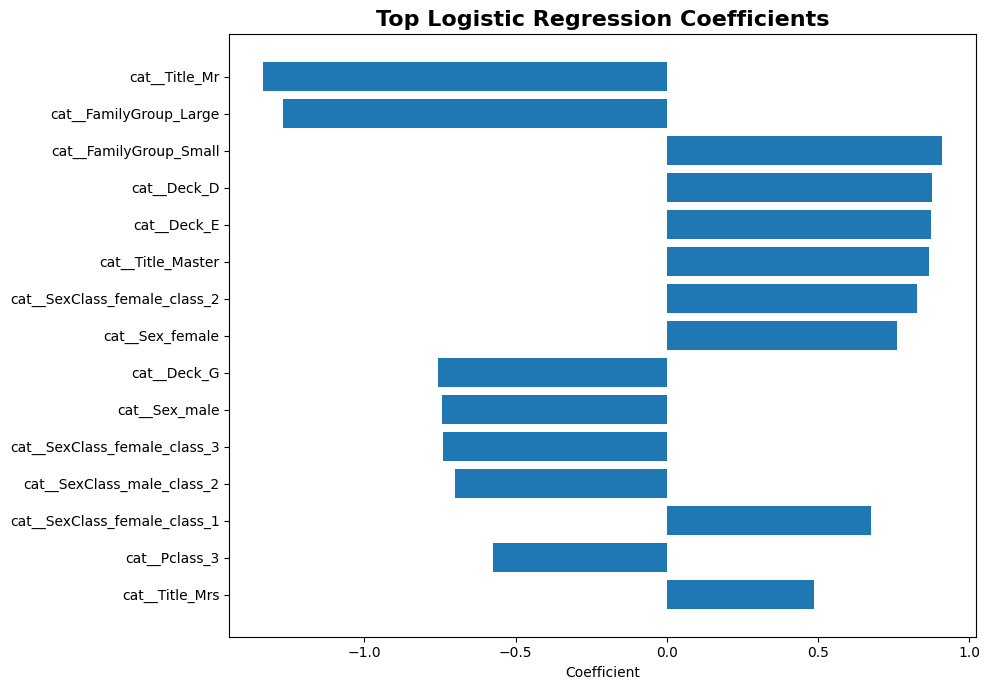

In [100]:
top_features = importance.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title(
    "Top Logistic Regression Coefficients",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Coefficient")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [101]:
import joblib

joblib.dump(
    logistic_pipeline,
    "model.joblib"
)

print("✅ Model saved successfully.")

✅ Model saved successfully.


In [102]:
loaded_model = joblib.load(
    "model.joblib"
)

print("Model reloaded successfully.")

Model reloaded successfully.


In [103]:
new_passenger = pd.DataFrame({

    "Pclass":[1],

    "Sex":["female"],

    "Age":[28],

    "Fare":[80],

    "Embarked":["C"],

    "Title":["Mrs"],

    "FamilySize":[2],

    "IsAlone":[0],

    "FamilyGroup":["Small"],

    "CabinKnown":[1],

    "Deck":["C"],

    "TicketGroupSize":[2],

    "FarePerPerson":[40],

    "AgeGroup":["YoungAdult"],

    "SexClass":["female_class_1"],

    "Mother":[0]

})

prediction = loaded_model.predict(new_passenger)[0]

probability = loaded_model.predict_proba(new_passenger)[0][1]

print("Prediction:")

print(
    "Survived"
    if prediction==1
    else
    "Did Not Survive"
)

print(f"Probability: {probability:.2%}")

Prediction:
Survived
Probability: 98.38%


# Final Conclusion

## Model Performance

The Logistic Regression model demonstrated strong predictive capability for the Titanic survival classification task.

### Final Results

- Accuracy: **84.4%**
- Precision: **83.6%**
- Recall: **73.9%**
- F1 Score: **78.5%**
- ROC-AUC: **86.5%**

### Key Findings

- Passenger gender was the strongest predictor of survival.
- First-class passengers had considerably higher survival rates than lower classes.
- Higher ticket fares were associated with better survival outcomes.
- Travelling with a small family generally increased survival compared with travelling alone or in very large groups.
- Feature engineering substantially improved model performance.

### Model Strengths

- End-to-end Scikit-learn pipeline
- Automatic preprocessing
- Robust evaluation
- Cross-validation
- Saved reusable model
- Explainable coefficients

### Future Improvements

- XGBoost
- LightGBM
- CatBoost
- Bayesian Hyperparameter Optimization
- SHAP Explainability
- Streamlit Web Application